# 1. Traversal

In [1]:
from collections import deque

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

class PrintGraph():
    def print_directed(self, adjacency_list):        
        graph_nodes = []
        for source_node, destination_nodes in adjacency_list.items():
            for destination_node in destination_nodes:
                graph_nodes.append((source_node, destination_node))

        graph = nx.DiGraph()
        graph.add_edges_from(graph_nodes)
        
        # Draw the graph
        plt.figure(figsize=(8, 6))
        nx.draw(graph, with_labels=True, node_size=1000, node_color="skyblue", font_size=15)
        plt.show()

    def print_undirected(self, adjacency_list):        
        graph_nodes = []
        for source_node, destination_nodes in adjacency_list.items():
            for destination_node in destination_nodes:
                graph_nodes.append((source_node, destination_node))

        graph = nx.Graph()
        graph.add_edges_from(graph_nodes)
        
        # Draw the graph
        plt.figure(figsize=(8, 6))
        nx.draw(graph, with_labels=True, node_size=1000, node_color="skyblue", font_size=15)
        plt.show()

    def print_weighted_graph(self, edges):
        '''
         edges = [(source_node, destination_node, weight), ()]
        '''
        G = nx.Graph()
        G.add_weighted_edges_from(edges)
        
        # Draw the graph
        pos = nx.spring_layout(G)  # Positions for all nodes
        
        # Draw nodes and edges
        nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10)
        
        # Draw edge labels (weights)
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
        
        # Show the plot
        plt.title("Weighted Graph")
        plt.show()

Edges:{1: [2, 3], 2: [5], 3: [], 4: [1], 5: [6], 6: []}
DFS Visited Nodes, Starting from 1 {1, 2, 3, 5, 6}
BFS Visited Nodes, Starting from 4 {4: 0, 1: 1, 2: 2, 3: 2, 5: 3, 6: 4}


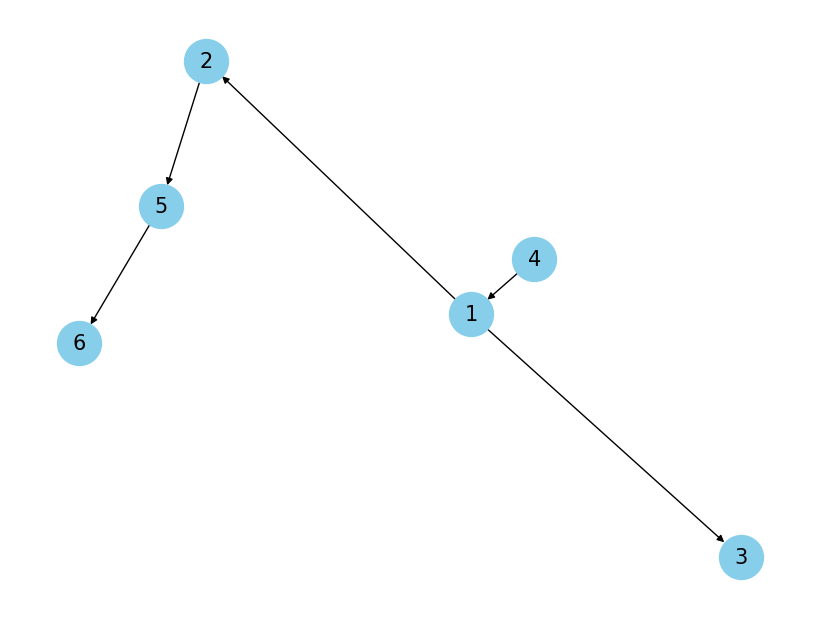

In [4]:
class Graph:
    def __init__(self):
        self.adjacency_list = {}

    def add_edge(self, source, destination):
        if source not in self.adjacency_list:
            self.adjacency_list[source] = []
        if destination not in self.adjacency_list:
            self.adjacency_list[destination] = []
        self.adjacency_list[source].append(destination)

    def print_nodes(self):
        print(f'Edges:{self.adjacency_list}')

    def print_graph(self):
        PrintGraph().print_directed(self.adjacency_list)
        
    def dfs(self, start_node):
        '''
        # TC: Each node and edge will be visited once (V + E)
        # SC: (V+E) for nodes and edges + V for visited nodes + V for call stack if all nodes are connected in sequence.
        Questions:
          - In a 2D matrix there are start and end nodes, and some nodes are blocked, We need to find if there exist a path from start to end node.
              Run DFS from starting point and in the end just check if destination node is visited or not.
        '''
        visited = set()

        def dfs_recursive(node):
            visited.add(node)  #for visited we can use a dictionary to store {node: graph component number}
            for neighbour in self.adjacency_list.get(node, []):
                if neighbour not in visited:
                    dfs_recursive(neighbour)

        dfs_recursive(start_node)
        return visited

    def bfs(self, start_node):
        '''
        - Uses a queue, 
        - T.C: O(V+E) as visiting each node & edge one time
        - S.C: O(V) for queue
        # Usecase:
            - It return the shortest path of unweighted graph, as for every node it will first visit with the shortest path.
            - To detect cycles
            - Questions:
                - In a 2D matrix there are start and end nodes, and some nodes are blocked, We need to find the shortest path from start to end node.
                      Run BFS from starting point and in the end just check if destination node is visited or not.

                - MultiSource BFS: In a 2D matrix, there are rotten oranges and good oranges, We need to calculate how much time it will take after
                                which all oranges become rotten
                                - Ans: Put all the rotten oranges in a queue, so every fresh orange will be visited once so TC (V ~= N*M).
                                       Time to reach the last fresh orange is considered as answer.
                                       
                                       
            
        '''
        queue = deque([start_node])
        traversal_order = [start_node]
        visited = {start_node}
        distance = { start_node: 0 }
        parent = {}
        
        while queue:
            node = queue.popleft()
            for neighbour in self.adjacency_list.get(node, []):
                # If neighbour not visited, then process it.
                if neighbour not in visited:
                    queue.append(neighbour)
                    visited.add(neighbour)
                    traversal_order.append(neighbour)
                    distance[neighbour] = distance[node] + 1
                    parent[neighbour] = node # to save path from node a to b
                

        return distance
            


graph = Graph()
graph.add_edge(1, 2)
graph.add_edge(1, 3)
graph.add_edge(4, 1)
graph.add_edge(5, 6)
graph.add_edge(2, 5)

graph.print_nodes()
print(f'DFS Visited Nodes, Starting from {1}', graph.dfs(1))
print(f'BFS Visited Nodes, Starting from {4}', graph.bfs(4))

graph.print_graph()


adjacency_list = graph.adjacency_list


# Questions

In [5]:

class Questions:
    def __init__(self):
        self.adjacency_list = {}

    def find_number_of_connected_components(self):
        # Find number of connected componenets
        # Ans: Call DFS on each node, increase count if node is unvisited
        # Fact: If we call DFS on one node a component, it should mark visited for all it's connected nodes.
        # this can only run on non-directional graph

        visited = {-1}
        number_of_connected_components = 0
        for source_node in self.adjacency_list.keys():
            if source_node not in visited:
                number_of_connected_components += 1

                # Call DFS
                #print("Each call to DFS", self.call_dfs(source_node))
                visited.update(self.call_dfs(source_node))
        print("No of connected components:", number_of_connected_components)

    def find_number_of_connected_components__find_no_of_islands(self):
        # Question: Given a 2D matrix, some nodes are blocked and some are valid for a path.
        def dfs(i,j,A):
            visited[i,j] +=1
            if check(i+1,j):
                dfs(i+1, j)
            if check(i,j+1):
                dfs(i, j+1)
            if check(i-1,j):
                dfs(i-1, j)
            if check(i,j-1):
                dfs(i, j-1)
                
        A = [[1,2], [3,4], [5,6]]
        N = len(A)
        M = len(A[0])
        visited = [[0] * M for i in range(N)]
        number_of_island = 0
        for i in N:
            for j in M:
                if visited[i][j] != 0:
                    number_of_island += 1
                    dfs(i,j)

    def shortest_path_in_binary_matrix(self):
        ''' BFS
        Problem: Given a 2D matrix where some blocks are blocked, return the shortest distance path from (0,0) to (n-1, m-1).
        Ans: Just run simple BSF, If last node is visited then the path exist else not.
        
        '''
        # Example Usage
        grid = [
            [0, 1, 0],
            [1, 0, 0],
            [1, 1, 0]
        ]

        N = len(grid)
        queue = deque([0,0,1]) # row, column, distance
        visited = {(0,0)}
        directions = [
            (-1, -1), (-1, 0), (-1, 1),
            (0, -1),          (0, 1),
            (1, -1), (1, 0), (1, 1)
        ]

        while queue:
            current_x, current_y, current_distance = queue.popleft()

            if current_x == N-1 and current_y == N-1:
                return current_distance
                
            for dx, dy in directions:
                new_x = current_x + dx
                new_y = current_y + dy
                if 0 <= new_x < N and 0<= new_y < N and (new_x, new_y) not in visited and grid[new_x, new_y] != 1:
                    visited.add((new_x, new_y))
                    queue.append((new_x, new_y, current_distance + 1))
        return -1
                
                
            
    def call_dfs(self, source_node):
        graph_temp = Graph()
        graph_temp.adjacency_list = self.adjacency_list
        return graph_temp.dfs(source_node)
        

questions = Questions()
questions.adjacency_list = graph.adjacency_list

questions.find_number_of_connected_components()



No of connected components: 2


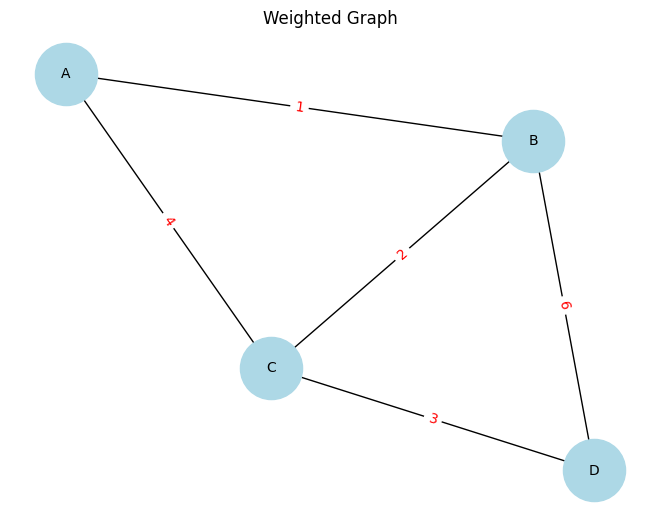

In [38]:
import heapq

WEIGHTED_GRAPH =  {
        'A': [('B', 1), ('C', 4)],
        'B': [('A', 1), ('C', 2), ('D', 6)],
        'C': [('A', 4), ('B', 2), ('D', 3)],
        'D': [('B', 6), ('C', 3)]
}

def print_weighted_graph():
    edges = list()
    for node, neighbours in WEIGHTED_GRAPH.items():
        for neighbour in neighbours:
            neighbour_node = neighbour[0]
            neighbour_weight = neighbour[1]
            edges.append((node, neighbour_node, neighbour_weight))
    PrintGraph().print_weighted_graph(edges)           


print_weighted_graph()


In [42]:

def dijkstra(start_node):
    """
    # It uses a priority queue.
    # T.C: O(V+ (E log E))      ~= O(V + E log V)
           
       - LogV is for min heap
    Find the shortest paths from the start node to all other nodes in the graph.

    :param graph: Dictionary where keys are nodes and values are lists of tuples (neighbor, weight)
    :param start: The starting node
    :return: A tuple (distances, previous) where:
             - distances is a dictionary mapping each node to its shortest distance from the start

    """    
    pq = []
    heapq.heappush(pq, (0, start_node))
    distances = { node: float('inf') for node in WEIGHTED_GRAPH.keys() }
    distances[start_node] = 0
    previous = {node: None for node in WEIGHTED_GRAPH.keys() }
    while pq:
        current_distance, current_node  = heapq.heappop(pq)

        # skip, if we already have a better path
        if current_distance > distances[current_node]:
            continue

        for neighbour, weight in WEIGHTED_GRAPH[current_node]:
            distance = current_distance + weight

            # If a new shorter path is found
            if distance < distances[neighbour]:
                distances[neighbour] = distance
                previous[neighbour] = current_node
                heapq.heappush(pq, (distance, neighbour))
    return distances, previous


def dijkstra_reconstruct_path(previous, start, end):
    """
    Reconstruct the shortest path from start to end using the previous dictionary.

    :param previous: Dictionary mapping nodes to their predecessors in the shortest path
    :param start: The starting node
    :param end: The destination node
    :return: A list representing the shortest path from start to end
    """
    path = []
    current = end
    while current is not None:
        path.append(current)
        current = previous[current]
    path.reverse()  # Reverse the path to get it from start to end
    return path if path[0] == start else []

dijkstra_output = dijkstra('A')
print("Dijkstra Distances", dijkstra_output[0])
print("Dijkstra child: parent path map", dijkstra_output[1])
print("Dijkstra print path for D", dijkstra_reconstruct_path(dijkstra_output[1], 'A', 'D'))

Dijkstra Distances {'A': 0, 'B': 1, 'C': 3, 'D': 6}
Dijkstra child: parent path map {'A': None, 'B': 'A', 'C': 'B', 'D': 'C'}
Dijkstra print path for D ['A', 'B', 'C', 'D']


# Floyd Warshall Algorithm


# 

# Minimum Spanning Tree

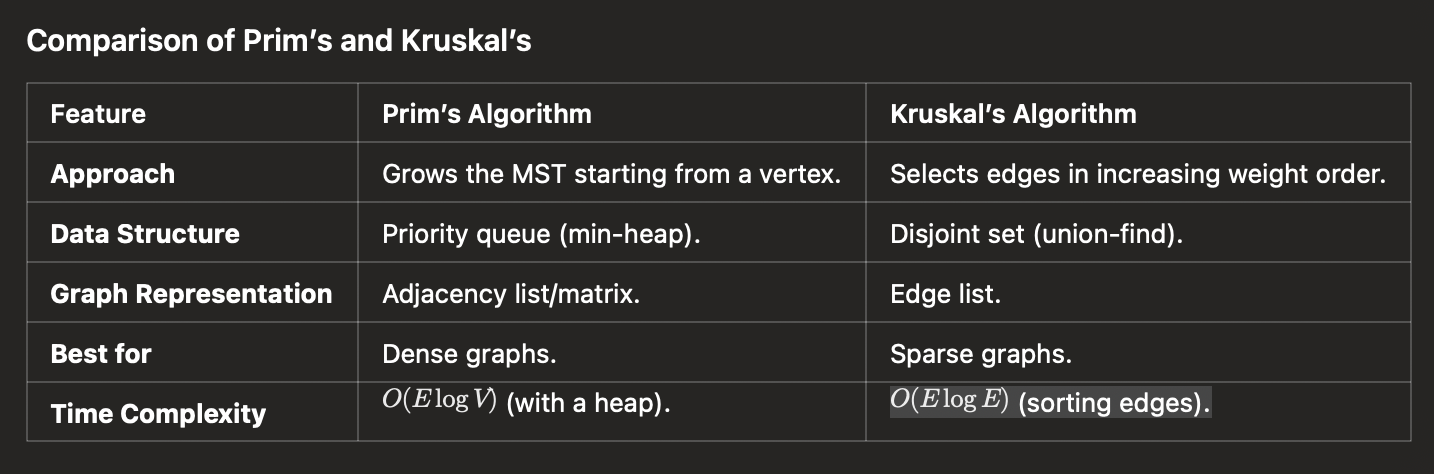

In [10]:
# Prim's Algorithm

import heapq
def prims_algo(graph, start):
    mst_cost = 0
    mst_edges = []
    visited = set()
    min_heap = [(0, start, None)] # (cost, current_node, parent)

    while min_heap:
        cost, current, parent = heapq.heappop(min_heap)

        if current in visited:
            continue

        visited.add(current)
        mst_cost += cost

        # To Ignore the first node edge, as the root node does not have a edge or parent.
        if parent is not None:
            mst_edges.append((parent, current, cost))

        for neighbour, weight in graph[current]:
            if neighbour not in visited:
                heapq.heappush(min_heap, (weight, neighbour, current))

    return mst_cost, mst_edges

# Example Usage
graph = {
    'A': [('B', 1), ('D', 3)],
    'B': [('A', 1), ('C', 4), ('D', 2)],
    'C': [('B', 4), ('D', 5)],
    'D': [('A', 3), ('B', 2), ('C', 5)]
}
mst_cost, mst_edges = prims_algo(graph, 'A')
print("MST Cost:", mst_cost)
print("MST Edges:", mst_edges)
        

MST Cost: 7
MST Edges: [('A', 'B', 1), ('B', 'D', 2), ('B', 'C', 4)]


SyntaxError: invalid syntax (2196177199.py, line 2)

# Disjoint set


Step 1: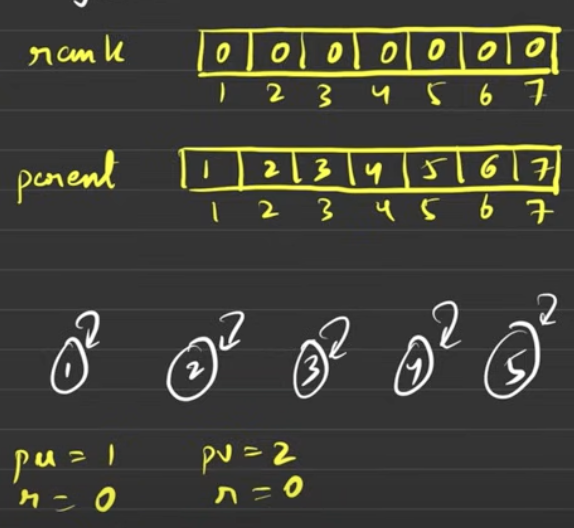  

Step 2: 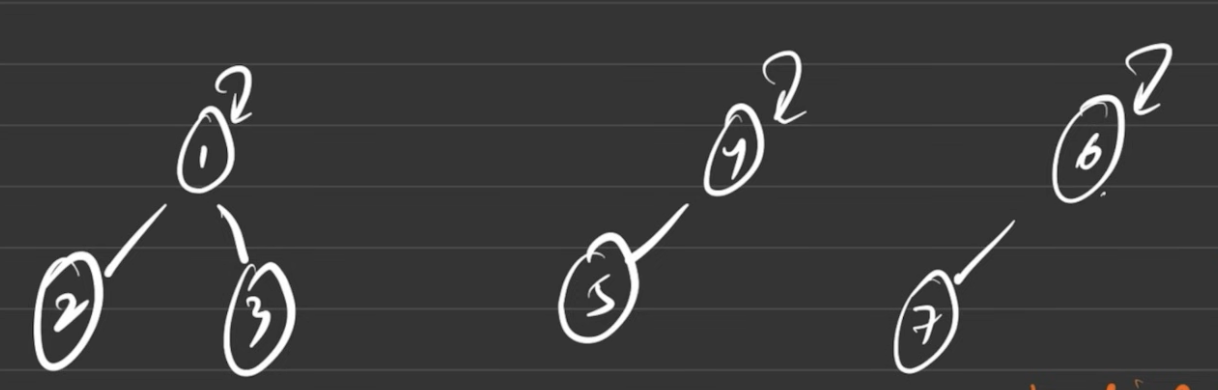

Step 3: 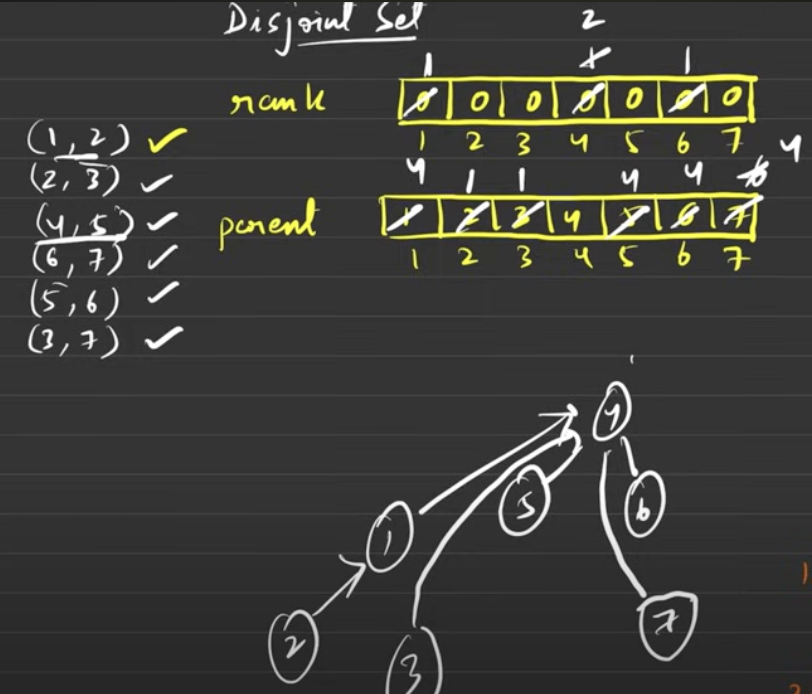

# Kuskal Algo
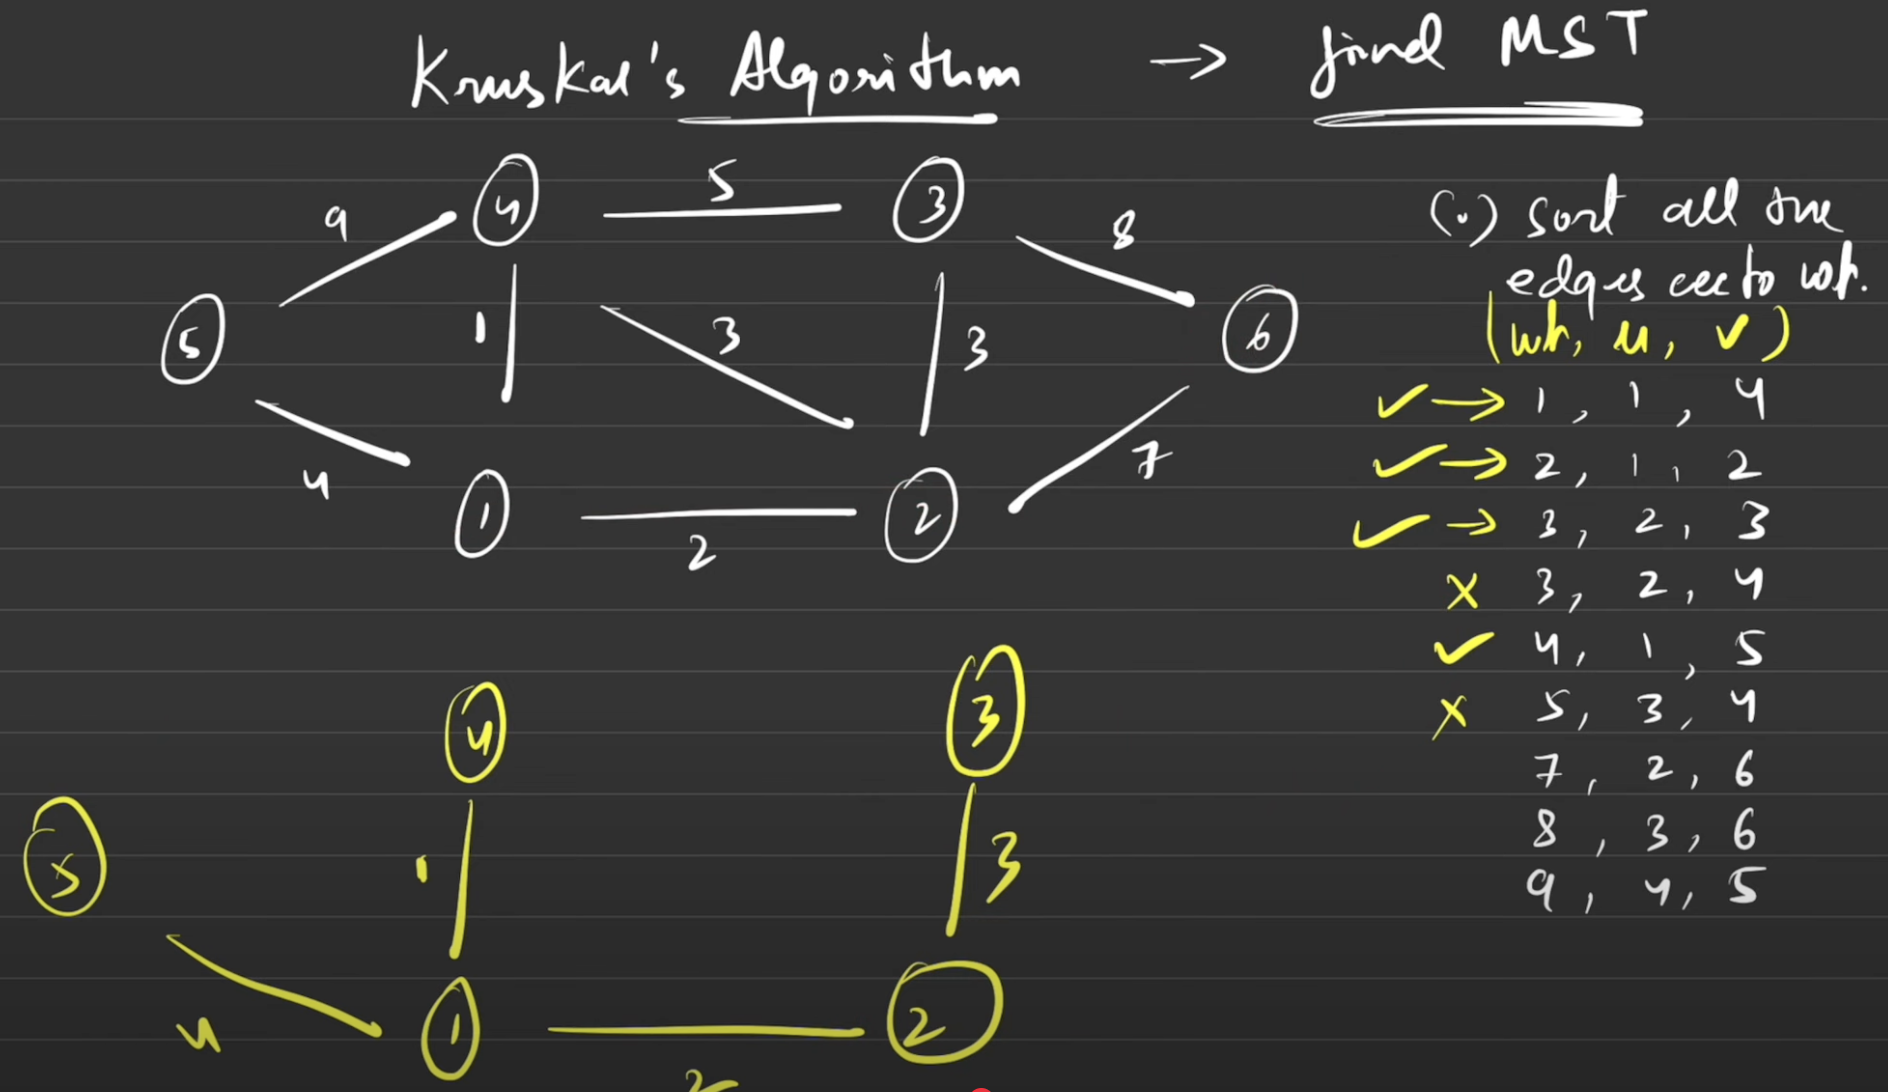

In [24]:
# https://www.youtube.com/watch?v=aBxjDBC4M1U&t=2177s

class DisjointSet:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        """
        It returns the ultimate root node of the tree.
        T.C.: O(alpah(n)), which means nearly constant
        
        Without path compression, the find operation behaves like traversing up the height of a tree, which can lead to  O(h) , where  h  is the height of the tree. In the worst-case scenario (without optimization), the height of the tree can become  O(n) , leading to linear complexity.
        With path compression in find method, the tree structure is flattened dynamically. Each node directly connects to the root when the find operation is performed, reducing the tree’s height over time. This flattening reduces the complexity to  O(\alpha(n)) , not  O(\log n) .

        """
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]  # this will return if node's parent is the same node, which is the root node only.

    def union(self, x, y):
        """
        T.C.: O(alpah(n)), which means nearly constant
        """
        root_x = self.find(x)
        root_y = self.find(y)
        if root_x != root_y:
            # smaller rank node/ tree gets attached with the higher rank.
            if self.rank[root_x] > self.rank[root_y]:
                self.parent[root_y] = root_x
            elif self.rank[root_x] < self.rank[root_y]:
                self.parent[root_x] = root_y
            else:
                self.parent[root_y] = root_x
                self.rank[root_x] += 1

def kruskals_algorithm(edges, num_nodes):
    """
    Find the Minimum Spanning Tree using Kruskal's Algorithm.
    T.C: O(E log E + E alpha(V)) = O(E log E)        # E log E -> for sorting, 
    :param edges: List of (weight, node1, node2) tuples.
    :param num_nodes: Number of vertices in the graph.
    :return: Minimum cost of MST and list of edges in MST.
    """
    ds = DisjointSet(num_nodes)
    mst_cost = 0
    mst_edges = []

    # Sort edges by weight
    edges.sort()

    # Iterate over all edges, check if the node exist in the same tree, if not then perform union (ie. add node to the tree) and consider it's edge.
    
    for weight, u, v in edges:
        if ds.find(u) != ds.find(v):
            print("Disjoint Set parent array: ", ds.parent)
            ds.union(u, v)
            mst_cost += weight
            mst_edges.append((u, v, weight))

    print("Disjoint Set parent array: ", ds.parent)
    return mst_cost, mst_edges

# Example Usage
edges = [
    (1, 0, 1),  # (weight, node1, node2)
    (4, 1, 2),
    (2, 1, 3),
    (3, 0, 3),
    (5, 2, 3),
]
num_nodes = 4
mst_cost, mst_edges = kruskals_algorithm(edges, num_nodes)
print("MST Cost:", mst_cost)
print("MST Edges:", mst_edges)

Disjoint Set parent array:  [0, 1, 2, 3]
Disjoint Set parent array:  [0, 0, 2, 3]
Disjoint Set parent array:  [0, 0, 2, 0]
Disjoint Set parent array:  [0, 0, 0, 0]
MST Cost: 7
MST Edges: [(0, 1, 1), (1, 3, 2), (1, 2, 4)]


# Tropical Sort

In [26]:
from collections import deque, defaultdict

def topological_sort(graph, num_vertices):
    # Step 1: Calculate in-degrees of all vertices
    in_degree = [0] * num_vertices
    for u in graph:
        for v in graph[u]:
            in_degree[v] += 1
    
    # Step 2: Initialize the queue with vertices of in-degree 0
    queue = deque([v for v in range(num_vertices) if in_degree[v] == 0])
    
    top_order = []
    while queue:
        current = queue.popleft()
        top_order.append(current)
        
        # Step 3: Decrease the in-degree of neighbors
        for neighbor in graph[current]:
            in_degree[neighbor] -= 1
            if in_degree[neighbor] == 0:
                queue.append(neighbor)
    
    # If all vertices are in top_order, it's valid; otherwise, there was a cycle
    if len(top_order) == num_vertices:
        return top_order
    else:
        raise ValueError("The graph is not a DAG, topological sort not possible.")

# Example usage
graph = {
    0: [1, 2],
    1: [3],
    2: [3],
    3: []
}
num_vertices = 4
print("Topological Sort (Algorithm):", topological_sort(graph, num_vertices))

Topological Sort (Kahn's Algorithm): [0, 1, 2, 3]


In [ ]:
Questions:
1. Check if there is a cycle in graph in undirected graph.
  - run simple dfs/bfs and check if any node is visted, if any neighbour node is visited and that node is not parent of current node, then there is a cycle.

2. Find minimum weight cycle in a undirected graph.
    •	Use the Floyd-Warshall algorithm to calculate all-pairs shortest paths.
	•	For every edge  (u, v) , check if the shortest path between  u  and  v  (excluding the edge itself) forms a cycle.
	•	Track the minimum weight cycle.

def find_min_weight_cycle(graph):
    """
    Finds the minimum weight cycle in an undirected graph.
    
    Parameters:
    graph: List[List[int]] - Adjacency matrix of the graph.
                              graph[i][j] represents the weight of the edge between i and j,
                              or float('inf') if no edge exists.
    
    Returns:
    int or None - Minimum weight of a cycle in the graph, or None if no cycle exists.
    """
    n = len(graph)  # Number of vertices
    dist = [[graph[i][j] for j in range(n)] for i in range(n)]  # Distance matrix
    min_cycle_weight = float('inf')

    # Floyd-Warshall Algorithm for all-pairs shortest paths
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if dist[i][j] > dist[i][k] + dist[k][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
    
    # Check for cycles
    for u in range(n):
        for v in range(n):
            if u != v and graph[u][v] < float('inf'):
                # Cycle weight is the shortest path between u and v + weight of edge (u, v)
                cycle_weight = dist[u][v] + graph[u][v]
                min_cycle_weight = min(min_cycle_weight, cycle_weight)
    
    return min_cycle_weight if min_cycle_weight < float('inf') else None



3. Check if there is a cycle in graph in directed graph.
  - Run DFS on the graph, and use 3 states of a node. If we reach any grey node at point of time, then there is a cycle.

    # Using DFS
    def isCyclicUtil(v, visited, recStack, graph):
        visited[v] = True
        recStack[v] = True
    
        for neighbor in graph[v]:
            if not visited[neighbor]:
                if isCyclicUtil(neighbor, visited, recStack, graph):
                    return True
            elif recStack[neighbor]:
                return True
    
        recStack[v] = False
        return False

    def isCyclic(graph, numVertices):
        visited = [False] * numVertices
        recStack = [False] * numVertices
    
        for node in range(numVertices):
            if not visited[node]:
                if isCyclicUtil(node, visited, recStack, graph):
                    return True
        return False

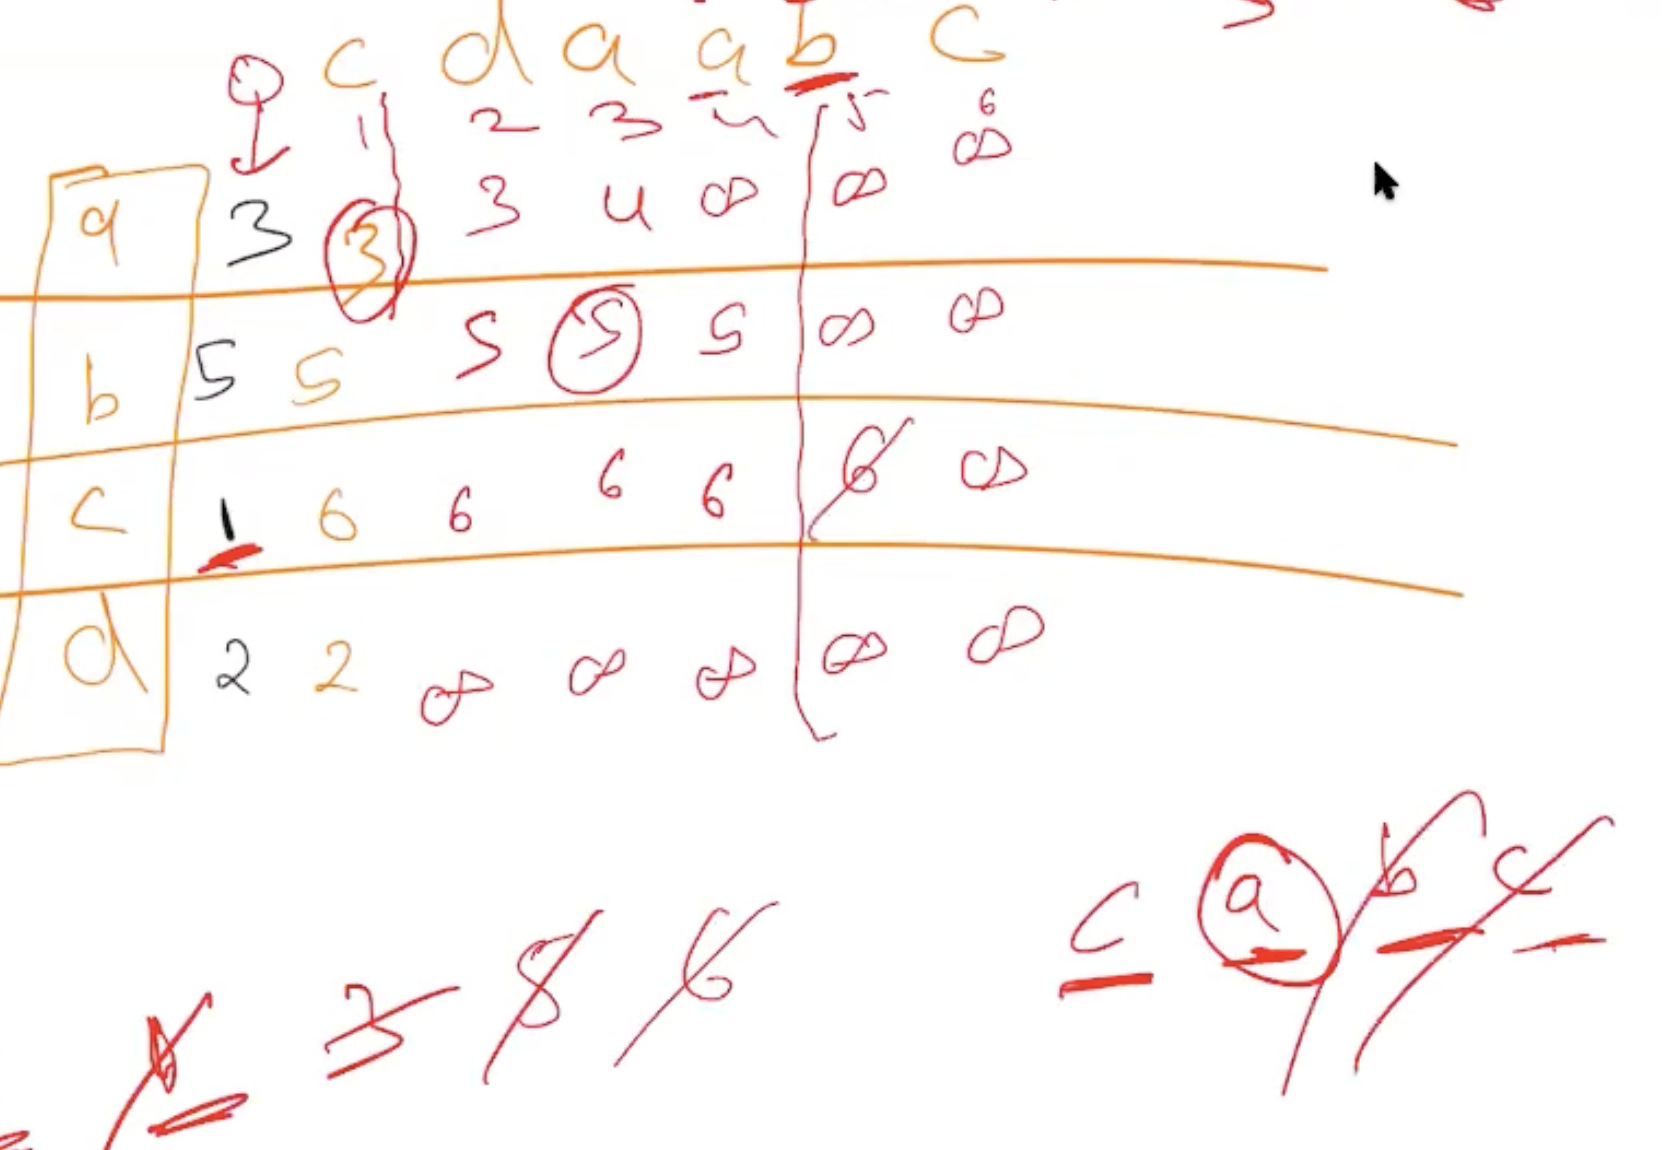